# Week 5 - Aido Rover Battery SoC Time-Series Analysis

This notebook applies time-series analysis methods to the synthetic Aido Rover
battery State of Charge (SoC) telemetry generated in Week 2.

The analysis focuses on the hourly mean battery SoC across the 30-unit fleet
over the 21-day observation period. The workflow includes time-series
decomposition, stationarity testing, ACF/PACF analysis, and forecasting.

The methodology follows the same general time-series analysis framework used
in atmospheric science research, transferring temporal pattern analysis from
environmental data to physical AI telemetry.

## Step 1 - Import Required Libraries

Import the libraries required for data preparation, time-series analysis,
statistical testing, forecasting, evaluation, and visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

## Step 2 - Load the Week 2 Telemetry Dataset

Load the synthetic Aido Rover telemetry dataset generated in Week 2.
The timestamp column is parsed as datetime so that the telemetry can be
aggregated and analyzed as a time series.

In [2]:
telemetry = pd.read_csv(
    "../Data/aido_rover_telemetry.csv",
    parse_dates=["timestamp"]
)

print("Dataset shape:", telemetry.shape)
print("Time range:", telemetry["timestamp"].min(), "to", telemetry["timestamp"].max())
print("Number of rovers:", telemetry["rover_id"].nunique())

telemetry.head()

Dataset shape: (181440, 20)
Time range: 2026-07-01 00:00:00 to 2026-07-21 23:55:00
Number of rovers: 30


,rover_id,timestamp,operational_mode,latitude,longitude,lidar_distance_m,wheel_torque_fl,wheel_torque_fr,wheel_torque_rl,wheel_torque_rr,imu_accel_x,imu_accel_y,imu_accel_z,ambient_temperature_c,battery_soc,task_success,gps_dropout_flag,lidar_saturation_flag,battery_drop_flag,sensor_noise_flag
0,AIDO_001,2026-07-01 00:00:00,PATROL,1.354202,103.821034,13.699527,15.488216,17.496137,18.483317,16.461332,0.027548,0.065830,9.635538,22.987241,76.428284,1,0,0,0,0
1,AIDO_001,2026-07-01 00:05:00,FAULT,1.354486,103.820582,0.486087,5.560991,19.340842,4.025754,12.218663,-0.209815,-0.043348,9.601425,21.239938,76.275079,1,0,0,0,0
2,AIDO_001,2026-07-01 00:10:00,ALERT,1.354647,103.820291,0.976473,35.108406,21.019085,15.790379,27.107367,-0.009860,-0.163633,9.721586,21.241867,76.155109,1,0,0,0,0
3,AIDO_001,2026-07-01 00:15:00,PATROL,1.353859,103.821427,6.150354,22.704654,16.397383,12.056365,20.362447,0.554334,-0.029707,9.735898,21.616087,76.014695,1,0,0,0,0
4,AIDO_001,2026-07-01 00:20:00,PATROL,1.354567,103.820920,12.263115,24.153797,10.759237,13.542237,20.654680,-0.063300,-0.234918,10.039323,21.213952,75.885342,1,0,0,0,0


## Step 3 - Prepare the Fleet Battery SoC Time Series

Aggregate the 5-minute battery SoC observations into hourly mean values
across the full 30-unit Aido Rover fleet.

This produces a single fleet-level time series for the 21-day observation
period and reduces short-term sensor-level variation before temporal analysis.

In [3]:
battery_hourly = (
    telemetry
    .set_index("timestamp")
    ["battery_soc"]
    .resample("1h")
    .mean()
)

print("Number of hourly observations:", len(battery_hourly))
print("Missing hourly observations:", battery_hourly.isna().sum())

battery_hourly.head()

Number of hourly observations: 504
Missing hourly observations: 0


timestamp
2026-07-01 00:00:00    85.468272
2026-07-01 01:00:00    85.088890
2026-07-01 02:00:00    84.399373
2026-07-01 03:00:00    83.830674
2026-07-01 04:00:00    83.369895
Freq: H, Name: battery_soc, dtype: float64

## Step 4 - Visualize the Fleet Battery SoC Time Series

Plot the hourly mean battery SoC across the 30-unit fleet over the full
21-day observation period.

This initial visualization is used to identify broad temporal patterns,
including repeated charging and discharging cycles, long-term trends,
and unusual fluctuations before formal time-series decomposition.

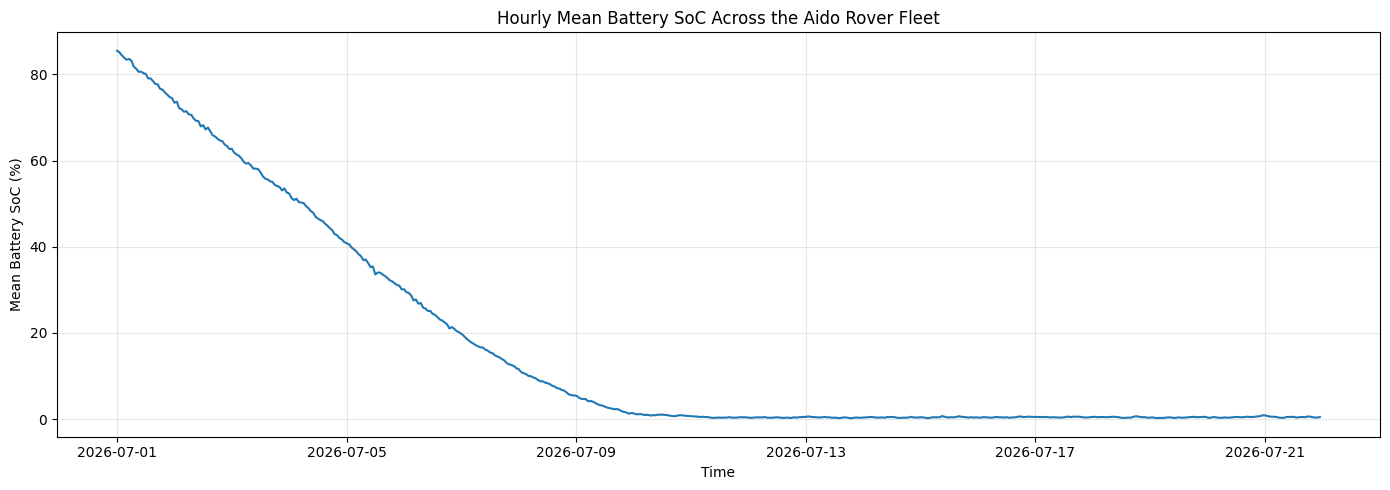

In [5]:
plt.figure(figsize=(14, 5))

plt.plot(
    battery_hourly.index,
    battery_hourly.values,
    linewidth=1.5
)

plt.title("Hourly Mean Battery SoC Across the Aido Rover Fleet")
plt.xlabel("Time")
plt.ylabel("Mean Battery SoC (%)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Figure 1. Hourly Mean Battery SoC Across the Aido Rover Fleet**  
The figure shows the hourly mean battery State of Charge (SoC) aggregated
across all 30 Aido Rover units over the 21-day observation period. The
time-series structure is examined quantitatively in the following analyses
to evaluate trend, periodicity, and stationarity.

## Step 5 - Initial Autocorrelation Check

Before selecting a seasonal period for decomposition, autocorrelation is
examined to identify whether the hourly fleet-average battery SoC contains
repeating temporal structure.

The autocorrelation function (ACF) measures the relationship between the
current battery SoC and its previous values at different time lags. Peaks at
regular lag intervals may indicate a recurring cycle in fleet battery behavior.

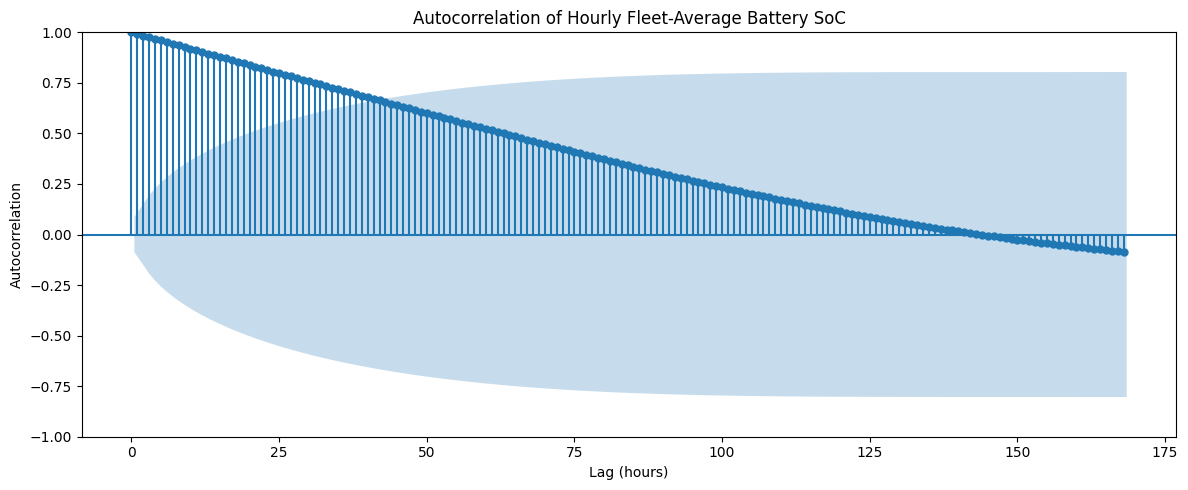

In [7]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(12, 5))

plot_acf(
    battery_hourly.dropna(),
    lags=168,
    ax=ax
)

ax.set_title("Autocorrelation of Hourly Fleet-Average Battery SoC")
ax.set_xlabel("Lag (hours)")
ax.set_ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

**Figure 2. Autocorrelation of Hourly Fleet-Average Battery SoC**  
The ACF remains positive across most of the examined lag range and declines
gradually as the lag increases, indicating strong temporal persistence in the
fleet-average battery SoC series. No clear repeating peaks are visible at
24-hour intervals, so the ACF does not provide strong evidence of a distinct
daily seasonal cycle. The slow decay in autocorrelation also suggests that
stationarity should be examined formally before selecting a forecasting model.

## Step 6 - Stationarity Testing

The Augmented Dickey-Fuller (ADF) test is used to determine whether the
hourly fleet-average battery SoC time series is stationary.

The null hypothesis (H0) states that the series contains a unit root and is
non-stationary. The alternative hypothesis (H1) states that the series is
stationary.

A p-value below 0.05 indicates sufficient evidence to reject the null
hypothesis and classify the series as stationary.

In [9]:
# ADF test on the raw hourly battery SoC series
adf_raw = adfuller(battery_hourly.dropna())

print("ADF Test - Raw Battery SoC")
print(f"ADF Statistic: {adf_raw[0]:.4f}")
print(f"p-value: {adf_raw[1]:.4f}")
print(f"Number of Lags Used: {adf_raw[2]}")
print(f"Number of Observations: {adf_raw[3]}")

print("\nCritical Values:")
for key, value in adf_raw[4].items():
    print(f"  {key}: {value:.4f}")

ADF Test - Raw Battery SoC
ADF Statistic: -2.9809
p-value: 0.0367
Number of Lags Used: 13
Number of Observations: 490

Critical Values:
  1%: -3.4438
  5%: -2.8675
  10%: -2.5699


### ADF Test Interpretation

The raw hourly fleet-average battery SoC series produced an ADF statistic of
-2.9809 with a p-value of 0.0367. Since the p-value is below the 0.05
significance level, the null hypothesis of a unit root is rejected.

Therefore, the raw battery SoC series is considered stationary at the 5%
significance level. Although the ACF showed persistent autocorrelation across
many lags, the ADF result indicates that first-order differencing is not
required to achieve stationarity.

## Step 7 - First Differencing and ADF Comparison

Although the raw battery SoC series was stationary at the 5% significance
level, first-order differencing is also evaluated for comparison.

First differencing measures the change in fleet-average battery SoC between
consecutive hourly observations. The ADF test is then applied to the
differenced series to determine how differencing affects stationarity.

In [10]:
# Calculate first-order difference
battery_diff = battery_hourly.diff().dropna()

print("Number of observations:", len(battery_diff))
battery_diff.head()

Number of observations: 503


timestamp
2026-07-01 01:00:00   -0.379382
2026-07-01 02:00:00   -0.689517
2026-07-01 03:00:00   -0.568699
2026-07-01 04:00:00   -0.460780
2026-07-01 05:00:00    0.188871
Freq: H, Name: battery_soc, dtype: float64

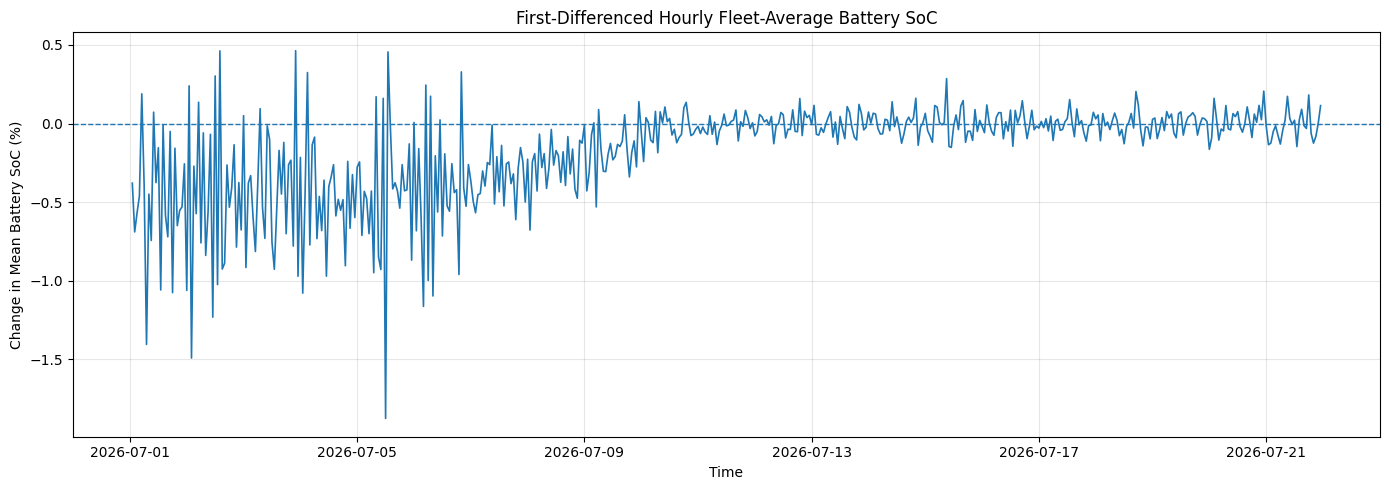

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    battery_diff.index,
    battery_diff.values,
    linewidth=1.2
)

ax.axhline(0, linewidth=1, linestyle="--")

ax.set_title("First-Differenced Hourly Fleet-Average Battery SoC")
ax.set_xlabel("Time")
ax.set_ylabel("Change in Mean Battery SoC (%)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Figure 3. First-Differenced Hourly Fleet-Average Battery SoC**

The differenced series represents the hour-to-hour change in fleet-average
battery SoC rather than the battery level itself. Positive values indicate
an increase in mean SoC from the previous hour, while negative values indicate
a decrease. The series fluctuates around zero, with both positive and negative
hourly changes observed throughout the 21-day period.

In [12]:
# ADF test on the first-differenced series
adf_diff = adfuller(battery_diff)

print("ADF Test - First-Differenced Battery SoC")
print(f"ADF Statistic: {adf_diff[0]:.4f}")
print(f"p-value: {adf_diff[1]:.4f}")
print(f"Number of Lags Used: {adf_diff[2]}")
print(f"Number of Observations: {adf_diff[3]}")

print("\nCritical Values:")
for key, value in adf_diff[4].items():
    print(f"  {key}: {value:.4f}")

ADF Test - First-Differenced Battery SoC
ADF Statistic: -1.3447
p-value: 0.6085
Number of Lags Used: 12
Number of Observations: 490

Critical Values:
  1%: -3.4438
  5%: -2.8675
  10%: -2.5699


### ADF Test - First-Differenced Series

The first-differenced battery SoC series produced an ADF statistic of -1.3447
with a p-value of 0.6085. Since the p-value is above the 0.05 significance
level, the null hypothesis of a unit root cannot be rejected.

In comparison, the raw series was stationary at the 5% significance level
(p = 0.0367). Therefore, first-order differencing does not improve the
stationarity evidence and is not required based on the ADF results.

## Step 8 - Time-Series Decomposition

STL (Seasonal-Trend decomposition using LOESS) is applied to separate the
hourly fleet-average battery SoC series into trend, seasonal, and residual
components.

A 24-hour seasonal period is used to specifically examine whether the battery
SoC series contains a daily recurring pattern. This period is evaluated as a
candidate daily cycle rather than assumed from the initial ACF results.

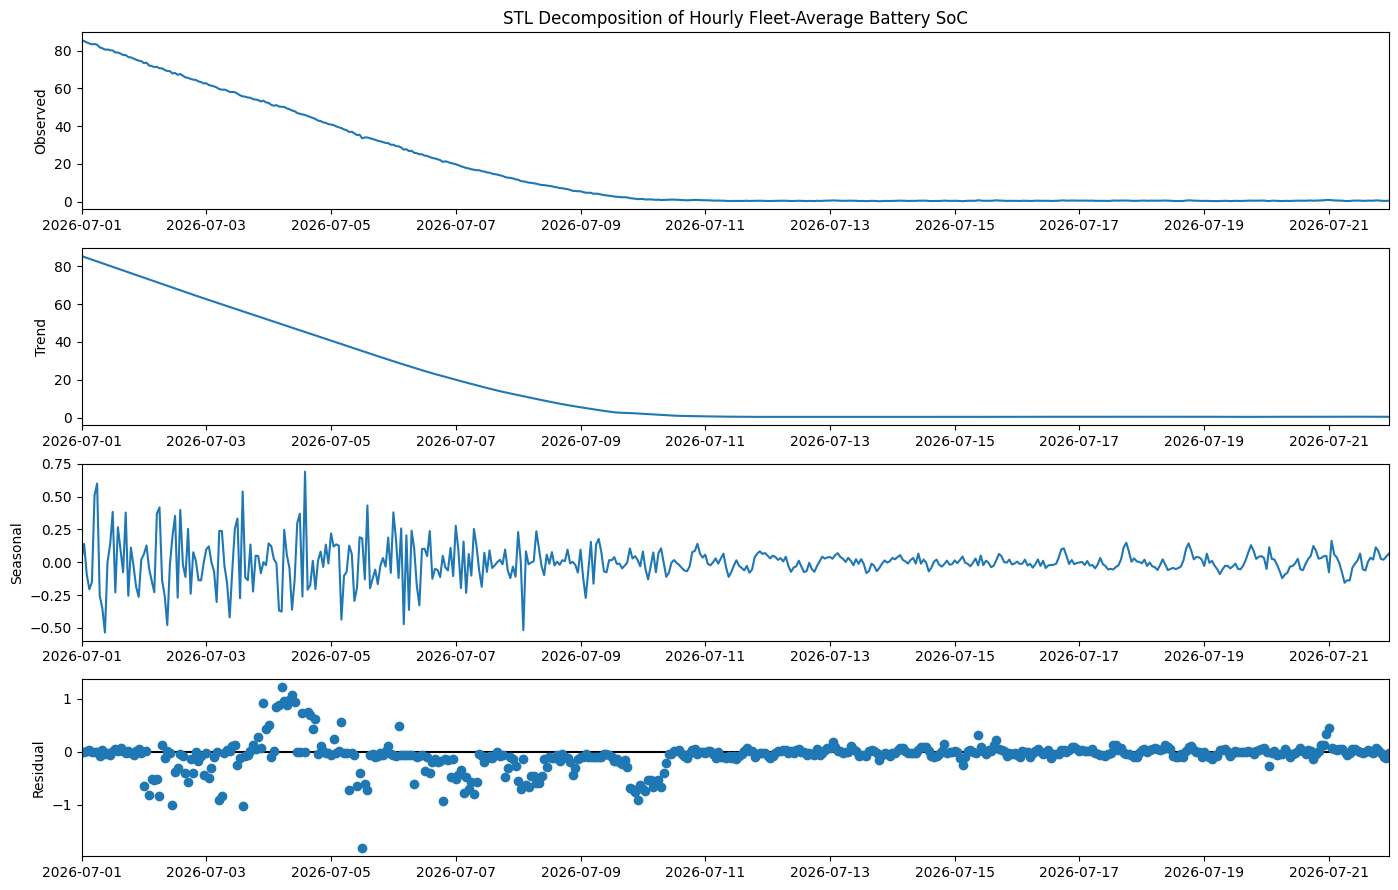

In [14]:
# STL decomposition using a 24-hour candidate seasonal period
stl = STL(
    battery_hourly.dropna(),
    period=24,
    robust=True
)

stl_result = stl.fit()

fig = stl_result.plot()
fig.set_size_inches(14, 9)

axes = fig.axes

axes[0].set_title("STL Decomposition of Hourly Fleet-Average Battery SoC")
axes[0].set_ylabel("Observed")
axes[1].set_ylabel("Trend")
axes[2].set_ylabel("Seasonal")
axes[3].set_ylabel("Residual")

plt.tight_layout()
plt.show()

**Figure 4. STL Decomposition of Hourly Fleet-Average Battery SoC**

The STL decomposition separates the fleet-average battery SoC into trend,
24-hour seasonal, and residual components. The trend component shows a clear
overall decline across the 21-day observation period, indicating a gradual
decrease in the underlying fleet-average SoC level over time.

The 24-hour seasonal component is relatively small compared with the trend
component, suggesting that daily seasonality is not the dominant source of
variation in fleet-average SoC. The residual component fluctuates around zero
with several larger deviations, indicating that some short-term variation
remains unexplained by the trend and 24-hour seasonal components.

## Step 9 - ACF and PACF Analysis for Model Selection

The autocorrelation function (ACF) and partial autocorrelation function (PACF)
are examined to evaluate the temporal dependence structure of the hourly
fleet-average battery SoC series.

The ACF measures the correlation between the series and its lagged values,
while the PACF measures the direct relationship at each lag after accounting
for the effects of shorter lags. Together, these plots help identify potential
autoregressive (AR) and moving-average (MA) components for forecasting.

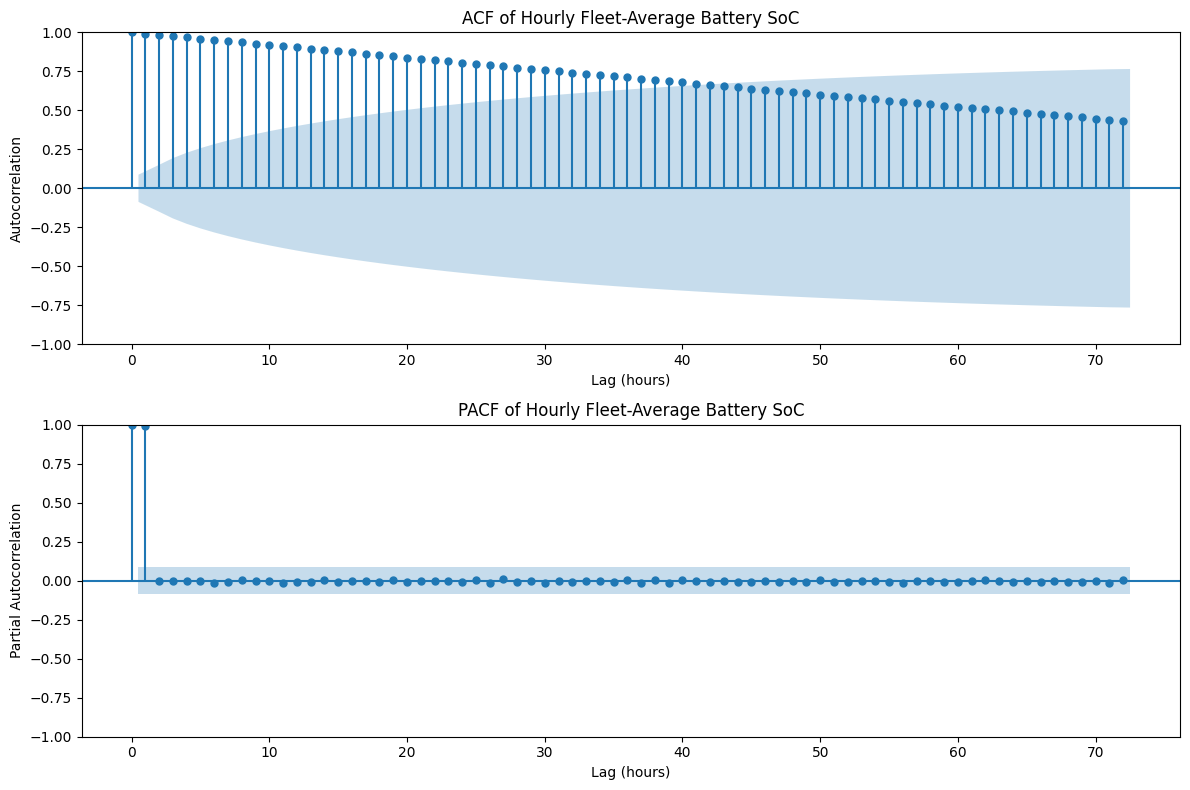

In [15]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# ACF
plot_acf(
    battery_hourly.dropna(),
    lags=72,
    ax=axes[0]
)
axes[0].set_title("ACF of Hourly Fleet-Average Battery SoC")
axes[0].set_xlabel("Lag (hours)")
axes[0].set_ylabel("Autocorrelation")

# PACF
plot_pacf(
    battery_hourly.dropna(),
    lags=72,
    ax=axes[1],
    method="ywm"
)
axes[1].set_title("PACF of Hourly Fleet-Average Battery SoC")
axes[1].set_xlabel("Lag (hours)")
axes[1].set_ylabel("Partial Autocorrelation")

plt.tight_layout()
plt.show()

**Figure 5. ACF and PACF of Hourly Fleet-Average Battery SoC**

The ACF decreases gradually across the examined lags rather than showing a
sharp cutoff, indicating persistent temporal dependence in the battery SoC
series. In contrast, the PACF shows a dominant positive spike at lag 1,
followed by substantially smaller partial autocorrelations at subsequent lags.

This pattern is consistent with a first-order autoregressive structure,
suggesting that an AR(1)-type model is an appropriate candidate for
forecasting the hourly fleet-average battery SoC.

## Step 10 - Train/Test Split for Forecasting

The 21-day hourly battery SoC series is divided chronologically into training
and testing periods. The first 14 days are used to train the forecasting
model, while the final 7 days are reserved for out-of-sample evaluation.

Because this is time-series data, the observations are not randomly shuffled.
Preserving chronological order ensures that the model is trained only on past
observations and evaluated on future observations.

In [16]:
# Split the 21-day series into 14 training days and 7 testing days
train_hours = 14 * 24

train = battery_hourly.iloc[:train_hours]
test = battery_hourly.iloc[train_hours:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

print("\nTraining period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

Training observations: 336
Testing observations: 168

Training period:
2026-07-01 00:00:00 to 2026-07-14 23:00:00

Testing period:
2026-07-15 00:00:00 to 2026-07-21 23:00:00


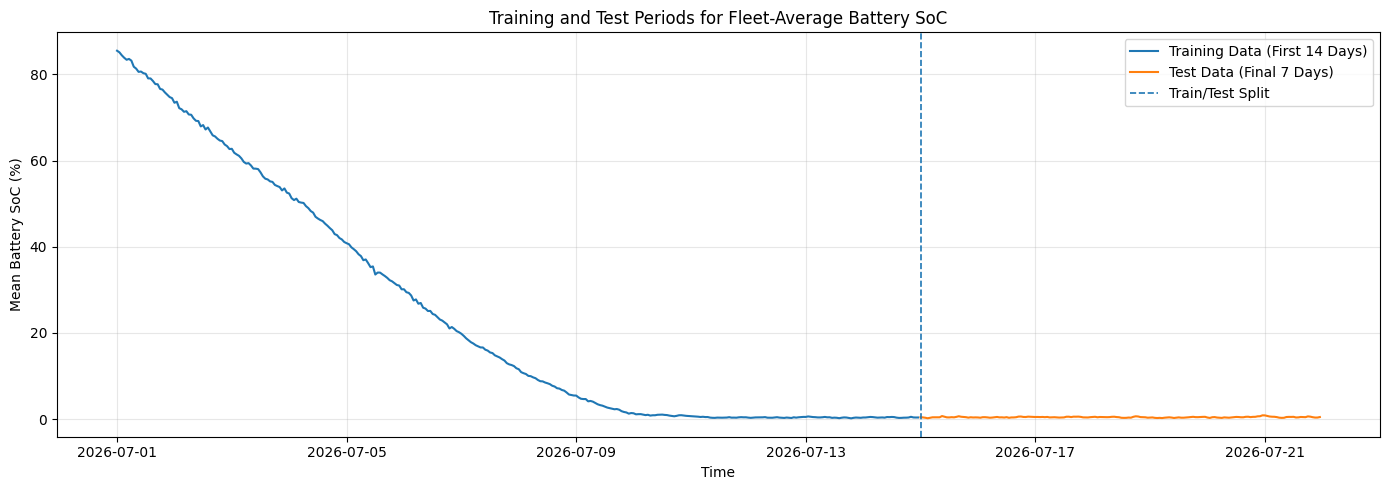

In [17]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    train.index,
    train.values,
    label="Training Data (First 14 Days)",
    linewidth=1.5
)

ax.plot(
    test.index,
    test.values,
    label="Test Data (Final 7 Days)",
    linewidth=1.5
)

ax.axvline(
    test.index[0],
    linestyle="--",
    linewidth=1.2,
    label="Train/Test Split"
)

ax.set_title("Training and Test Periods for Fleet-Average Battery SoC")
ax.set_xlabel("Time")
ax.set_ylabel("Mean Battery SoC (%)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Figure 6. Training and Test Periods for Fleet-Average Battery SoC**

The first 14 days (336 hourly observations) are used as the training period,
while the final 7 days (168 hourly observations) are reserved for testing.
The chronological split preserves the temporal ordering of the series and
allows forecasting performance to be evaluated on observations not used
during model fitting.

## Step 11 - ARIMA Forecasting Model

Based on the ACF and PACF analysis, an ARIMA(1,0,0) model is selected as the
initial forecasting model. The dominant lag-1 PACF suggests a first-order
autoregressive component, while the ADF test indicates that differencing is
not required.

The model is fitted using the first 14 days of hourly battery SoC observations
and used to forecast the final 7-day test period.

In [18]:
# Fit ARIMA(1,0,0) to the training period
arima_model = ARIMA(
    train,
    order=(1, 0, 0)
)

arima_result = arima_model.fit()

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:            battery_soc   No. Observations:                  336
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -194.741
Date:                Tue, 01 Sep 2026   AIC                            395.483
Time:                        03:16:00   BIC                            406.934
Sample:                    07-01-2026   HQIC                           400.048
                         - 07-14-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         29.3740    236.437      0.124      0.901    -434.034     492.782
ar.L1          1.0000      0.001    946.421      0.000       0.998       1.002
sigma2         0.1815      0.011     15.985      0.0

### ARIMA(1,0,0) Model Interpretation

The fitted ARIMA(1,0,0) model produced a lag-1 autoregressive coefficient
of approximately 1.00 (p < 0.001), indicating very strong dependence between
consecutive hourly battery SoC observations.

The coefficient is close to the unit-root boundary, which is consistent with
the strong temporal persistence observed in the ACF. Although the earlier ADF
test rejected the unit-root null hypothesis at the 5% significance level,
the AR estimate suggests that the stationarity of the series is relatively
borderline and should be interpreted cautiously.

In [19]:
# Forecast the final 7-day test period
forecast_result = arima_result.get_forecast(steps=len(test))

forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int(alpha=0.05)

# Align forecast index with the test period
forecast_mean.index = test.index
forecast_ci.index = test.index

forecast_mean.head()

timestamp
2026-07-15 00:00:00    0.398313
2026-07-15 01:00:00    0.399595
2026-07-15 02:00:00    0.400877
2026-07-15 03:00:00    0.402158
2026-07-15 04:00:00    0.403440
Freq: H, Name: predicted_mean, dtype: float64

## Step 12 - Forecast Evaluation

Forecast performance is evaluated against the held-out 7-day test period
using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

MAE measures the average absolute difference between predicted and observed
battery SoC, while RMSE gives greater weight to larger forecast errors.
Lower values indicate better forecasting performance.

In [20]:
mae = mean_absolute_error(test, forecast_mean)
rmse = np.sqrt(mean_squared_error(test, forecast_mean))

print("ARIMA(1,0,0) Forecast Performance")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

ARIMA(1,0,0) Forecast Performance
MAE:  0.0966
RMSE: 0.1231


### Forecast Performance

The ARIMA(1,0,0) model achieved an MAE of 0.0966 and an RMSE of 0.1231 on
the 7-day test period. These values indicate that the forecasts were, on
average, close to the observed fleet-average battery SoC values.

The slightly higher RMSE compared with MAE indicates some variation in
forecast error magnitude, but the overall out-of-sample prediction errors
remain small.

## Step 13 - Forecast Visualization

The ARIMA(1,0,0) forecast is compared with the observed battery SoC values
during the 7-day test period. A 95% prediction interval is included to
represent the uncertainty associated with the forecast.

This visualization is used to evaluate whether the model captures the
temporal behavior of the held-out battery SoC observations in addition to
the numerical MAE and RMSE metrics.

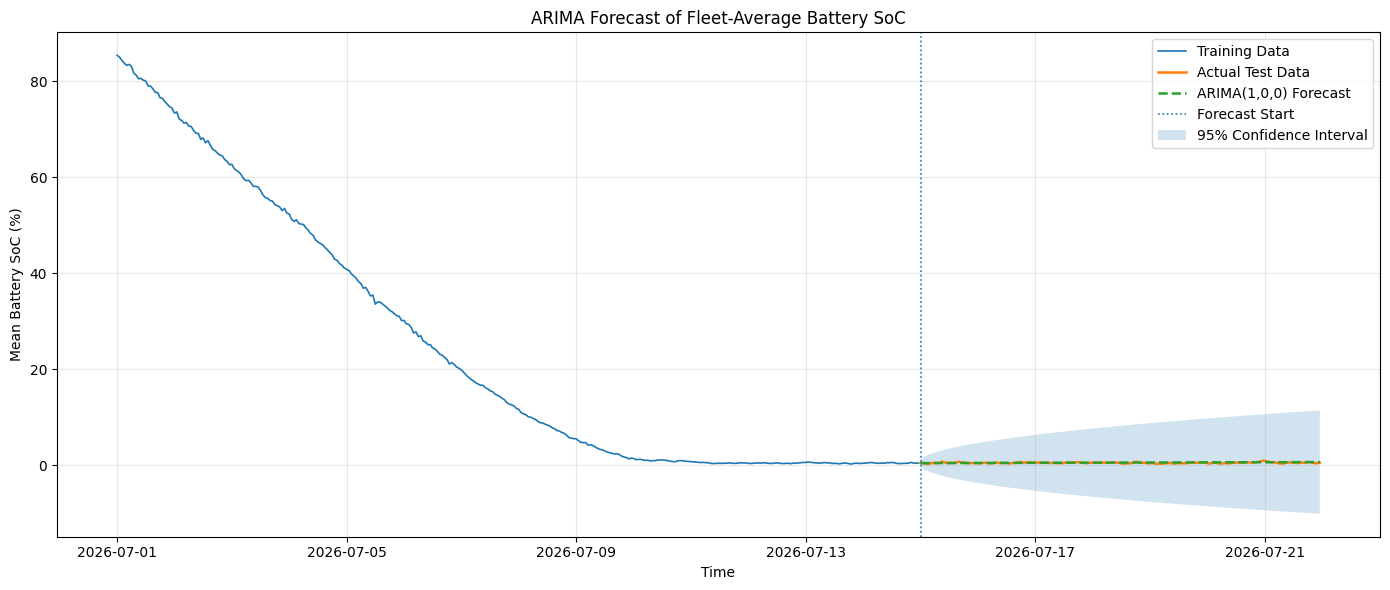

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))

# Training data
ax.plot(
    train.index,
    train.values,
    label="Training Data",
    linewidth=1.2
)

# Actual test data
ax.plot(
    test.index,
    test.values,
    label="Actual Test Data",
    linewidth=1.8
)

# ARIMA forecast
ax.plot(
    forecast_mean.index,
    forecast_mean.values,
    label="ARIMA(1,0,0) Forecast",
    linewidth=1.8,
    linestyle="--"
)

# 95% confidence interval
ax.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.2,
    label="95% Confidence Interval"
)

# Mark train/test boundary
ax.axvline(
    test.index[0],
    linestyle=":",
    linewidth=1.2,
    label="Forecast Start"
)

ax.set_title("ARIMA Forecast of Fleet-Average Battery SoC")
ax.set_xlabel("Time")
ax.set_ylabel("Mean Battery SoC (%)")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Figure 7. ARIMA Forecast of Fleet-Average Battery SoC**

The ARIMA(1,0,0) forecast remains close to the observed battery SoC values
throughout the 7-day test period. Both the forecast and actual observations
remain at relatively low and stable SoC levels, consistent with the low MAE
and RMSE obtained during forecast evaluation.

The 95% prediction interval widens as the forecast horizon increases,
reflecting increasing uncertainty for longer-term predictions. The strong
forecast performance should be interpreted in the context of the relatively
low variability of the test period, as the model is primarily forecasting
a stable low-SoC state rather than the larger decline observed earlier in
the time series.

## Step 14 - Exponential Smoothing Benchmark

A Holt exponential smoothing model is fitted as an alternative forecasting
approach to compare with the ARIMA(1,0,0) model.

The model includes an additive trend component to account for the gradual
change in fleet-average battery SoC over time. A seasonal component is not
included because the previous ACF and STL analyses did not provide strong
evidence that a 24-hour seasonal cycle is a dominant feature of the series.

In [22]:
# Fit Holt exponential smoothing with an additive trend
holt_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal=None,
    initialization_method="estimated"
)

holt_result = holt_model.fit()

print("Holt Exponential Smoothing Parameters")
print(f"Level smoothing (alpha): {holt_result.params['smoothing_level']:.4f}")
print(f"Trend smoothing (beta):  {holt_result.params['smoothing_trend']:.4f}")

Holt Exponential Smoothing Parameters
Level smoothing (alpha): 0.4277
Trend smoothing (beta):  0.1254


In [23]:
# Forecast the final 7-day test period
holt_forecast = holt_result.forecast(len(test))

# Align forecast index with the test period
holt_forecast.index = test.index

holt_forecast.head()

timestamp
2026-07-15 00:00:00    0.410032
2026-07-15 01:00:00    0.410585
2026-07-15 02:00:00    0.411137
2026-07-15 03:00:00    0.411690
2026-07-15 04:00:00    0.412242
Freq: H, dtype: float64

In [24]:
holt_mae = mean_absolute_error(test, holt_forecast)
holt_rmse = np.sqrt(mean_squared_error(test, holt_forecast))

print("Holt Exponential Smoothing Forecast Performance")
print(f"MAE:  {holt_mae:.4f}")
print(f"RMSE: {holt_rmse:.4f}")

Holt Exponential Smoothing Forecast Performance
MAE:  0.0818
RMSE: 0.1076


## Step 15 - Forecast Model Comparison

The ARIMA(1,0,0) and Holt exponential smoothing models are compared using
their out-of-sample MAE and RMSE on the same 7-day test period. The model
with lower forecast errors provides better predictive performance for the
held-out observations.

In [25]:
model_comparison = pd.DataFrame({
    "Model": [
        "ARIMA(1,0,0)",
        "Holt Exponential Smoothing"
    ],
    "MAE": [
        mae,
        holt_mae
    ],
    "RMSE": [
        rmse,
        holt_rmse
    ]
})

model_comparison

,Model,MAE,RMSE
0,"ARIMA(1,0,0)",0.096613,0.123109
1,Holt Exponential Smoothing,0.081831,0.107555


### Model Comparison Interpretation

Holt exponential smoothing achieved lower forecast errors than ARIMA(1,0,0)
on the 7-day test period. Holt produced an MAE of 0.0818 and an RMSE of
0.1076, compared with an MAE of 0.0966 and an RMSE of 0.1231 for ARIMA.

The results indicate that explicitly modeling the evolving level and trend
provides slightly better out-of-sample performance for this battery SoC
series. Therefore, Holt exponential smoothing is selected as the final
forecasting model.

## Step 16 - Final Holt Forecast Visualization

The selected Holt exponential smoothing model is visualized against the
observed values in the 7-day test period. This allows the final model's
forecast behavior to be evaluated visually in addition to the MAE and RMSE
metrics.

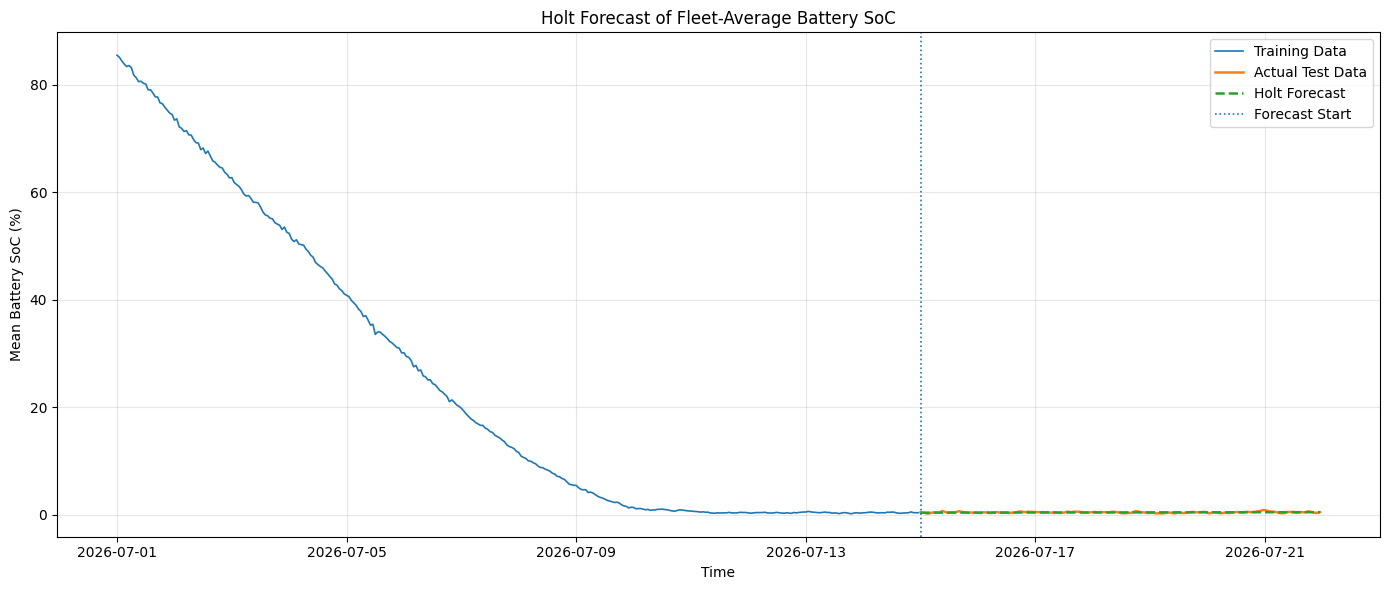

In [26]:
fig, ax = plt.subplots(figsize=(14, 6))

# Training data
ax.plot(
    train.index,
    train.values,
    label="Training Data",
    linewidth=1.2
)

# Actual test data
ax.plot(
    test.index,
    test.values,
    label="Actual Test Data",
    linewidth=1.8
)

# Holt forecast
ax.plot(
    holt_forecast.index,
    holt_forecast.values,
    label="Holt Forecast",
    linewidth=1.8,
    linestyle="--"
)

# Mark forecast start
ax.axvline(
    test.index[0],
    linestyle=":",
    linewidth=1.2,
    label="Forecast Start"
)

ax.set_title("Holt Forecast of Fleet-Average Battery SoC")
ax.set_xlabel("Time")
ax.set_ylabel("Mean Battery SoC (%)")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Figure 8. Holt Forecast of Fleet-Average Battery SoC**

The Holt forecast follows the declining pattern of the observed battery SoC
during the 7-day test period and remains close to the actual observations.
Compared with the ARIMA(1,0,0) forecast, the Holt model better preserves the
underlying downward trend, which is consistent with its lower MAE and RMSE.

Both the observed and forecast values approach very low SoC levels during the
test period. Therefore, the strong forecast performance should also be
interpreted in the context of the relatively low variability of the held-out
test data.

## Step 17 - Holt Forecast Uncertainty

Because the Holt exponential smoothing implementation does not directly
provide analytical forecast intervals, an approximate 95% prediction interval
is constructed using the standard deviation of the model residuals.

Forecast uncertainty is allowed to increase with the forecast horizon,
reflecting the greater uncertainty associated with predictions further into
the future.

In [27]:
# Calculate residual standard deviation from the training period
holt_residuals = train - holt_result.fittedvalues
residual_std = holt_residuals.std()

# Forecast horizon
h = np.arange(1, len(test) + 1)

# Approximate forecast uncertainty increases with horizon
forecast_se = residual_std * np.sqrt(h)

# 95% prediction interval
holt_lower = holt_forecast - 1.96 * forecast_se
holt_upper = holt_forecast + 1.96 * forecast_se

print(f"Residual standard deviation: {residual_std:.4f}")

Residual standard deviation: 0.2432


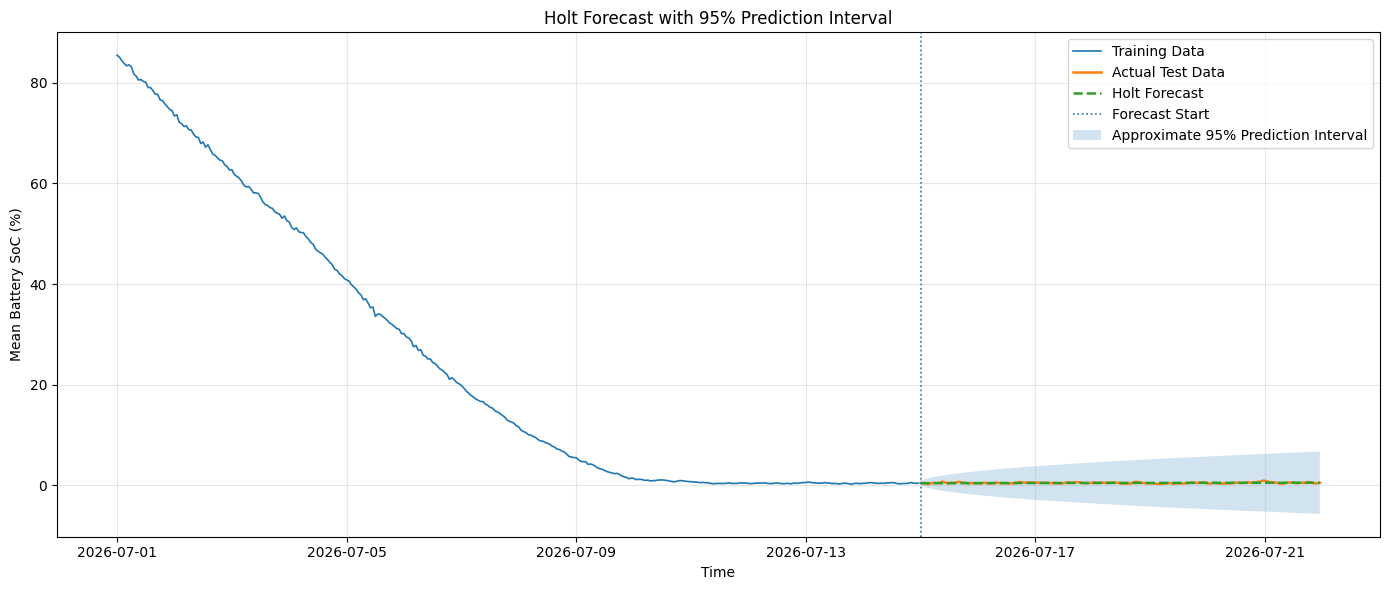

In [28]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    train.index,
    train.values,
    label="Training Data",
    linewidth=1.2
)

ax.plot(
    test.index,
    test.values,
    label="Actual Test Data",
    linewidth=1.8
)

ax.plot(
    holt_forecast.index,
    holt_forecast.values,
    label="Holt Forecast",
    linewidth=1.8,
    linestyle="--"
)

ax.fill_between(
    test.index,
    holt_lower,
    holt_upper,
    alpha=0.2,
    label="Approximate 95% Prediction Interval"
)

ax.axvline(
    test.index[0],
    linestyle=":",
    linewidth=1.2,
    label="Forecast Start"
)

ax.set_title("Holt Forecast with 95% Prediction Interval")
ax.set_xlabel("Time")
ax.set_ylabel("Mean Battery SoC (%)")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Figure 9. Holt Forecast with Approximate 95% Prediction Interval**

The Holt forecast remains close to the observed fleet-average battery SoC
during the 7-day test period. The approximate 95% prediction interval widens
substantially as the forecast horizon increases, reflecting the cumulative
uncertainty introduced by the residual-based interval approximation.

The interval becomes considerably wider than the observed variation in the
test period and extends below the physically meaningful lower bound of 0%
SoC. Therefore, this interval should be interpreted as a conservative
approximation of forecast uncertainty rather than an exact analytical
prediction interval.

## Step 18 - Bootstrap-Based Prediction Interval

To provide a more data-driven estimate of forecast uncertainty, a bootstrap
approach is used to construct an empirical 95% prediction interval for the
Holt forecast.

Training residuals are randomly resampled and added to the point forecasts
across repeated simulations. The 2.5th and 97.5th percentiles of the simulated
forecast distribution are then used as the lower and upper bounds of the
95% prediction interval.

In [29]:
# Remove missing residual values
residuals = holt_residuals.dropna().values

# Number of bootstrap simulations
n_bootstrap = 1000

# Store simulated forecasts
bootstrap_forecasts = np.zeros((n_bootstrap, len(test)))

# Reproducibility
rng = np.random.default_rng(42)

for i in range(n_bootstrap):
    sampled_residuals = rng.choice(
        residuals,
        size=len(test),
        replace=True
    )

    bootstrap_forecasts[i, :] = (
        holt_forecast.values + sampled_residuals
    )

# Calculate empirical 95% prediction interval
bootstrap_lower = np.percentile(
    bootstrap_forecasts,
    2.5,
    axis=0
)

bootstrap_upper = np.percentile(
    bootstrap_forecasts,
    97.5,
    axis=0
)

print("Bootstrap simulations:", n_bootstrap)
print("Forecast horizon:", len(test), "hours")

Bootstrap simulations: 1000
Forecast horizon: 168 hours


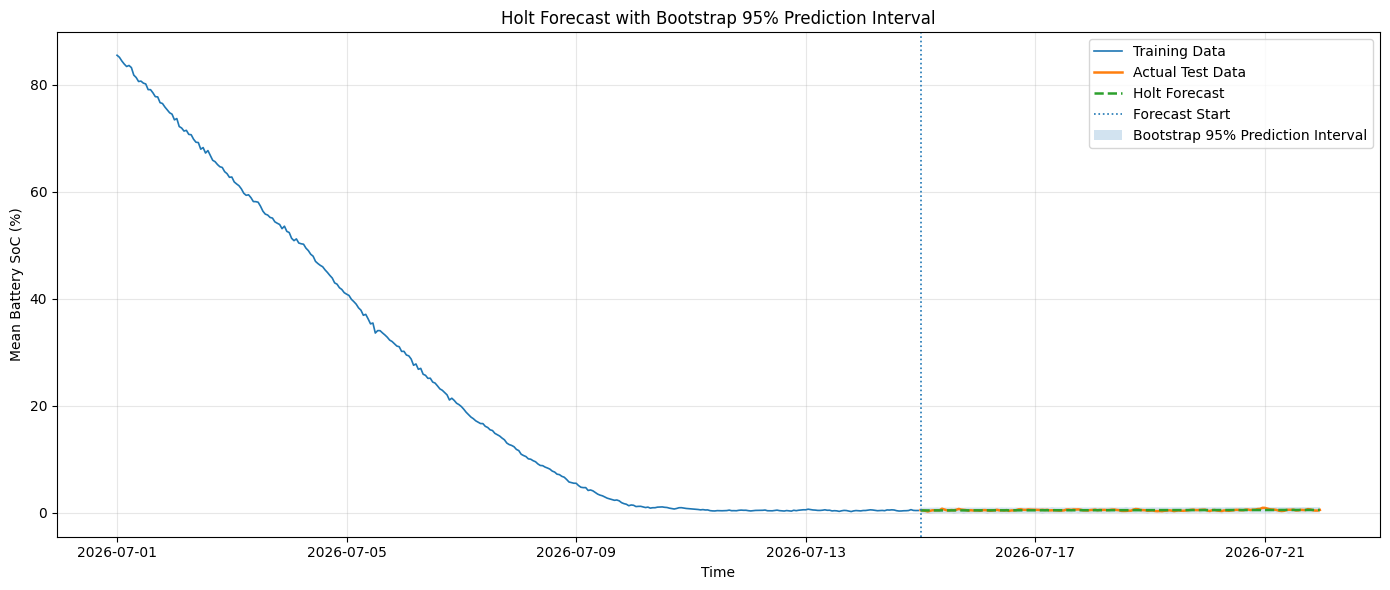

In [30]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    train.index,
    train.values,
    label="Training Data",
    linewidth=1.2
)

ax.plot(
    test.index,
    test.values,
    label="Actual Test Data",
    linewidth=1.8
)

ax.plot(
    holt_forecast.index,
    holt_forecast.values,
    label="Holt Forecast",
    linewidth=1.8,
    linestyle="--"
)

ax.fill_between(
    test.index,
    bootstrap_lower,
    bootstrap_upper,
    alpha=0.2,
    label="Bootstrap 95% Prediction Interval"
)

ax.axvline(
    test.index[0],
    linestyle=":",
    linewidth=1.2,
    label="Forecast Start"
)

ax.set_title("Holt Forecast with Bootstrap 95% Prediction Interval")
ax.set_xlabel("Time")
ax.set_ylabel("Mean Battery SoC (%)")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Figure 10. Holt Forecast with Bootstrap 95% Prediction Interval**

The Holt forecast remains close to the observed fleet-average battery SoC
throughout the 7-day test period, with all test observations falling within
the bootstrap-based prediction interval.

Compared with the residual-based approximation in Figure 9, the bootstrap
interval remains relatively narrow because it is constructed from the
empirical distribution of the training residuals without accumulating
forecast uncertainty across the prediction horizon.

### Prediction Interval Coverage

The bootstrap-based 95% prediction interval achieved 100% empirical coverage
over the 168-hour test period. Although this indicates that all observed test
values were captured by the interval, the result should not be interpreted as
evidence of perfect uncertainty calibration. The high coverage may partly
reflect the low variability of the test period and the characteristics of the
residual-bootstrap approximation.

## Summary

This analysis examined the hourly fleet-average battery SoC of the Aido Rover
fleet over a 21-day period. STL decomposition identified a clear overall
downward trend, while the 24-hour seasonal component was relatively weak.
The raw series was stationary at the 5% significance level
(ADF statistic = -2.9809, p = 0.0367), and first-order differencing was
therefore not required. ACF and PACF analysis showed strong temporal
persistence with a dominant lag-1 relationship.

ARIMA(1,0,0) and Holt exponential smoothing were evaluated using the first
14 days for training and the final 7 days for testing. Holt achieved the
better forecasting performance, with an MAE of 0.0818 and an RMSE of 0.1076,
compared with 0.0966 and 0.1231 for ARIMA. Holt was therefore selected as
the final forecasting model, with prediction intervals used to evaluate
forecast uncertainty.

Overall, the analysis demonstrates that fleet-level battery telemetry contains
strong temporal structure that can be used for short-term energy forecasting.
However, the low variability of the final test period and the synthetic nature
of the dataset should be considered when interpreting the forecast performance.